In [2]:
import pandas as pd

df = pd.read_csv("energy_cleaned.csv")
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Country     6 non-null      str  
 1   %Renewable  6 non-null      int64
 2   Region      6 non-null      str  
dtypes: int64(1), str(2)
memory usage: 276.0 bytes


,%Renewable
count,6.000000
mean,60.333333
std,25.136958
min,35.000000
25%,45.750000
50%,49.000000
75%,79.250000
max,95.000000


Question: Are there any unusual values or column names?
- no unsual values or column names apart from "%renewable" starting with symbol

In [ ]:
high_renew = df[df["%Renewable"] > 70]
print("Countries with >70% renewable energy:", len(high_renew))

proportion = len(df[df["%Renewable"] > 70]) / len(df)
print(f"Proportion using mostly renewable energy: {proportion:.0%}") #added to answer question 33% use mostly renewable energy

Countries with >70% renewable energy: 2
Proportion using mostly renewable energy: 33%


Region
Africa           50.0
Asia             67.0
Europe           48.0
Oceania          35.0
South America    95.0
Name: %Renewable, dtype: float64


<Axes: xlabel='Region'>

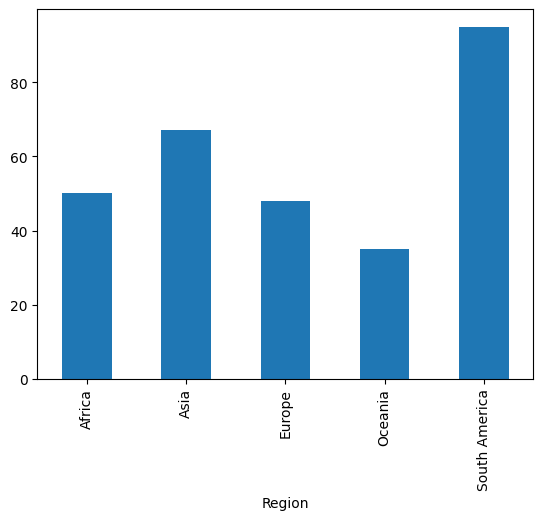

In [9]:
region_avg = df.groupby("Region")["%Renewable"].mean()
print(region_avg)
region_avg.plot(kind='bar')

Question: Which region has the highest average renewable use?
- south america

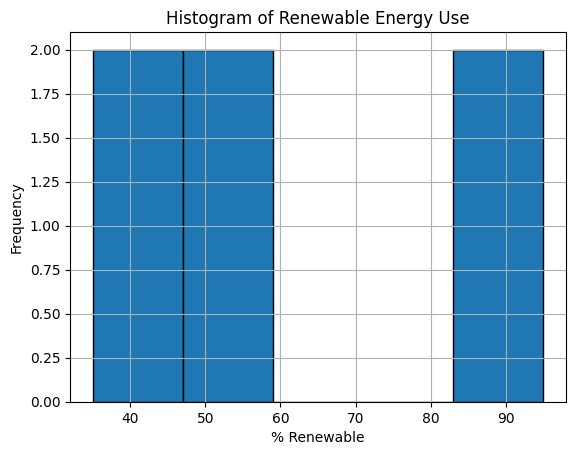

In [11]:
import matplotlib.pyplot as plt

df["%Renewable"].plot(kind="hist", bins=5, edgecolor="black")
plt.title("Histogram of Renewable Energy Use")
plt.xlabel("% Renewable")
plt.grid(True)
plt.show()

Question: Are most countries clustered around certain values?
yes the countries cluster into two groups, four sit around 35-50% and others sit around 85-95%

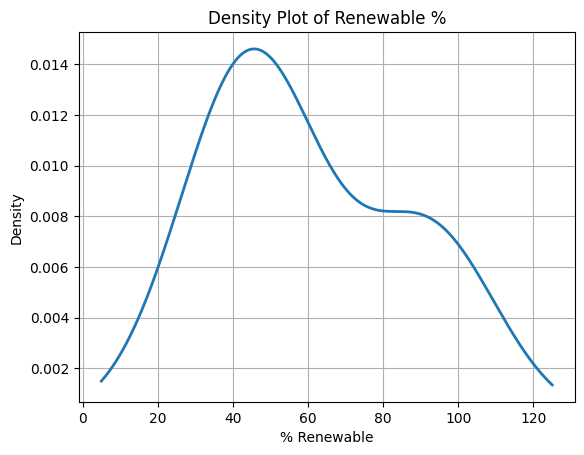

In [12]:

df["%Renewable"].plot(kind="density", linewidth=2)
plt.title("Density Plot of Renewable %")
plt.xlabel("% Renewable")
plt.grid(True)
plt.show()

Question: Does the distribution appear normal, skewed, or multimodal?
The distribution isnt normal its main peak is around 45% with another around 90% which gives it a multi modal shape (two humps) its also right skewed

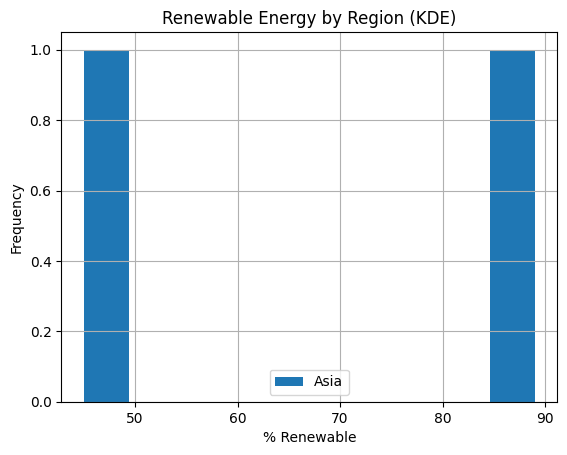

In [15]:
for region, group in df.groupby("Region"):
    if len(group) >= 2:
        group["%Renewable"].plot(kind="hist", label=region)

plt.title("Renewable Energy by Region (KDE)")
plt.xlabel("% Renewable")
plt.legend()
plt.grid(True)
plt.show()

Question: Which region has the highest consistency in renewable use?
asia is the only country with 2+ to show a distribution, every other country only has 1, so consistency cant be measured preoperly